In [29]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# Find project root (folder containing pyproject.toml), then add src/
project_root = None
p = Path.cwd().resolve()
for d in [p, *p.parents]:
    if (d / "pyproject.toml").exists():
        project_root = d
        sys.path.insert(0, str(d / "src"))
        break
if project_root is None:
    raise RuntimeError("Could not find project root (pyproject.toml)")

from smatrix import square_lattice, S_disconnected, create_self_energy_interpolator_numba,t
from eigenstate_solving.eigen_eq_integrand import BZ_proj

sigma_path = project_root / "data" / "sigma_grid0f1a.npz"
if not sigma_path.exists():
    raise FileNotFoundError(f"Missing data file: {sigma_path}")

sigma_data = np.load(sigma_path)
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)


E = 2*square_lattice.omega_e

n_samples = 2

print(E)
trans_amp = t(np.array([190,60]),E,square_lattice)
print(trans_amp)
print(abs(trans_amp))


200.0
(-0.29106482558991464-0.9572390382167854j)
1.0005125231509517


In [27]:
np.sqrt(190**2+60**2)

np.float64(199.24858845171275)

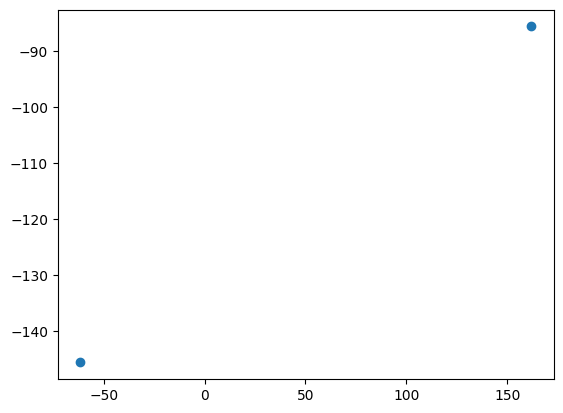

In [13]:
k_para_list = []
for i in range(0,n_samples):
    U = np.random.uniform(0,1.0)
    theta = np.random.uniform(0,2*np.pi)

    kx= E * np.sqrt(U) * np.cos(theta)
    ky = E * np.sqrt(U) * np.sin(theta)
    k_para_list.append(np.array([kx,ky]))
k_para_list = np.array(k_para_list)
#print(np.shape(k_para_list))

plt.scatter(k_para_list[:,0],k_para_list[:,1])


In [15]:
Q_para = np.array([0,0])
samples = np.empty(2,dtype=complex)

for k_para in k_para_list:
    l_para = BZ_proj(Q_para - k_para,square_lattice)
    width = E - np.linalg.norm(k_para) - np.linalg.norm(l_para)
    if width <= 0:
        continue

    eps = 1e-3 # aviod zero division error
    E1_grid = np.linspace(np.linalg.norm(k_para) + eps,E-np.linalg.norm(l_para)-eps,10)
    for E1 in E1_grid:
        E2 = E - E1
        value = S_disconnected(k_para,E1,l_para,E2,square_lattice,sigma_func_period_numba)
        samples = np.append(samples,value)

print(samples)
#plt.scatter(samples.real,samples.imag)



[10. +388.72796297j 36.5+402.72796297j]
